In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import convnext_tiny

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
BASE_PATH = "/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2"

TRAIN_DIR = f"{BASE_PATH}/train"
VAL_DIR   = f"{BASE_PATH}/val"
TEST_DIR  = f"{BASE_PATH}/test"

IMG_SIZE = 300
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [5]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 73995
Val: 9245
Test: 9261


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [7]:
from collections import Counter

counter = Counter(train_dataset.targets)

total = sum(counter.values())

weights = []

for i in range(5):
    weights.append(
        total / (5 * counter[i])
    )

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(DEVICE)

print(weights)

tensor([ 0.2683,  3.9933,  1.2211, 14.7107,  7.3921], device='cuda:0')


In [8]:
model = convnext_tiny(
    weights="DEFAULT"
)

model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    5
)

model = model.to(DEVICE)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 209MB/s]  


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=5, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

In [11]:
def train_epoch():

    model.train()

    running_loss = 0

    preds = []
    labels_all = []

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred = outputs.argmax(1)

        preds.extend(pred.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(
        labels_all,
        preds
    )

    return (
        running_loss / len(train_loader),
        acc
    )

In [12]:
def validate():

    model.eval()

    running_loss = 0

    preds = []
    labels_all = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            pred = outputs.argmax(1)

            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(
        labels_all,
        preds
    )

    qwk = cohen_kappa_score(
        labels_all,
        preds,
        weights="quadratic"
    )

    return (
        running_loss / len(val_loader),
        acc,
        qwk
    )

In [14]:
best_qwk = 0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch()

    val_loss, val_acc, qwk = validate()

    scheduler.step(qwk)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")

    print(f"Val QWK    : {qwk:.4f}")

    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_convnext_model.pth"
        )

        print("Model Saved")

print("\nBest QWK:", best_qwk)

  0%|          | 3/4625 [00:02<1:04:04,  1.20it/s]


KeyboardInterrupt: 

In [15]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/best_convnext_model.pth",
        map_location=DEVICE
    )
)

model.eval()

preds = []
labels_all = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        pred = outputs.argmax(1)

        preds.extend(pred.cpu().numpy())
        labels_all.extend(labels.numpy())

In [16]:
acc = accuracy_score(
    labels_all,
    preds
)

qwk = cohen_kappa_score(
    labels_all,
    preds,
    weights="quadratic"
)

print("Accuracy:", acc)
print("QWK:", qwk)

print(
    classification_report(
        labels_all,
        preds,
        digits=4
    )
)

Accuracy: 0.8486124608573589
QWK: 0.8042795970947128
              precision    recall  f1-score   support

           0     0.9197    0.9488    0.9340      6896
           1     0.3011    0.3004    0.3008       466
           2     0.7451    0.6278    0.6814      1518
           3     0.3810    0.3125    0.3433       128
           4     0.6141    0.7233    0.6642       253

    accuracy                         0.8486      9261
   macro avg     0.5922    0.5826    0.5848      9261
weighted avg     0.8442    0.8486    0.8452      9261



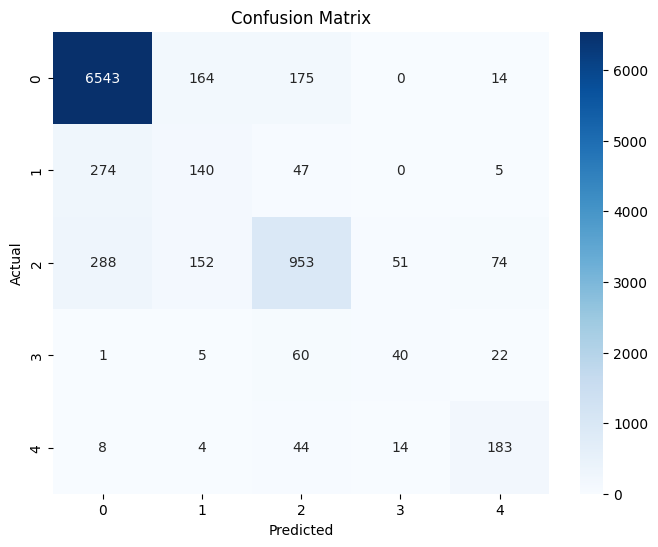

In [17]:
cm = confusion_matrix(
    labels_all,
    preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()